# Walk-forward daily limit validation

Select a discount using only a trailing training window, then score that fixed discount on the following unseen year.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px

from retail_sp500.daily_data import daily_data_summary, load_or_fetch_twelve_data_daily

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

from retail_sp500.limit_portfolio import walk_forward_recurring_limit_selection

In [2]:
SYMBOL = "SPY"
START_DATE = "2007-06-01"
CACHE_PATH = Path("data/processed/spy_daily_1day.csv")
REFRESH = False

daily = load_or_fetch_twelve_data_daily(
    os.getenv("TWELVE_DATA_API_KEY"),
    cache_path=CACHE_PATH,
    refresh=REFRESH,
    symbol=SYMBOL,
    start_date=START_DATE,
)

source = daily_data_summary(daily, symbol=SYMBOL)
print(source)
assert source["interval"] == "1day"
assert daily.index.max() <= pd.Timestamp.today().normalize()
daily.tail()

{'source': 'CSV cache: data/processed/spy_daily_1day.csv', 'symbol': 'SPY', 'interval': '1day', 'start': '2007-06-01', 'end': '2026-07-14', 'sessions': 4809}


,open,high,low,close,volume
date,,,,,
2026-07-08,743.159970,746.150020,739.510010,745.400020,43767400
2026-07-09,747.349980,751.969970,745.590030,751.710020,41441700
2026-07-10,752.049988,755.419980,748.099976,754.950010,42191300
2026-07-13,752.469970,753.909970,748.000000,749.169980,44013600
2026-07-14,750.909970,753.299990,748.659970,751.830020,35135286


## Walk-forward configuration

In [3]:
DISCOUNTS = np.arange(0.0, 0.0301, 0.001)
TRAIN_YEARS = 5
TEST_YEARS = 1
MAX_WAIT_SESSIONS = 5

walk_forward = walk_forward_recurring_limit_selection(
    daily,
    DISCOUNTS,
    train_years=TRAIN_YEARS,
    test_years=TEST_YEARS,
    step_years=1,
    max_wait_sessions=MAX_WAIT_SESSIONS,
    monthly_contribution=1_000,
)

walk_forward

,train_start,train_end,test_start,test_end,selected_discount,train_ending_excess_value,test_ending_excess_value,test_ending_excess_pct_of_contributions,test_limit_fill_rate,test_forced_fill_rate,test_average_wait_sessions
0,2007-06-04,2012-06-03,2012-06-04,2013-06-03,0.029000,93.171135,-104.807461,-0.008734,0.000000,1.000000,5.000000
1,2008-06-04,2013-06-03,2013-06-04,2014-06-03,0.004000,2.066878,17.889137,0.001491,1.000000,0.000000,2.166667
2,2009-06-04,2014-06-03,2014-06-04,2015-06-03,0.006000,15.944307,24.539573,0.002045,0.833333,0.166667,2.333333
3,2010-06-04,2015-06-03,2015-06-04,2016-06-03,0.006000,115.428899,-7.729379,-0.000644,0.916667,0.083333,1.833333
4,2011-06-04,2016-06-03,2016-06-04,2017-06-03,0.014000,192.534233,-50.119314,-0.004177,0.000000,1.000000,5.000000
5,2012-06-04,2017-06-03,2017-06-04,2018-06-03,0.006000,158.456302,4.762239,0.000397,0.666667,0.333333,3.000000
6,2013-06-04,2018-06-03,2018-06-04,2019-06-03,0.007000,100.879804,1.513978,0.000126,0.750000,0.250000,3.000000
7,2014-06-04,2019-06-03,2019-06-04,2020-06-03,0.007000,52.198502,-76.499977,-0.006375,0.833333,0.166667,2.416667
8,2015-06-04,2020-06-03,2020-06-04,2021-06-03,0.005000,11.141390,-164.409933,-0.013701,0.833333,0.166667,3.333333
9,2016-06-04,2021-06-03,2021-06-04,2022-06-03,0.002000,-126.517760,34.194032,0.002850,1.000000,0.000000,1.416667


## Out-of-sample summary

In [4]:
walk_forward_summary = pd.Series({
    "folds": len(walk_forward),
    "median_selected_discount": walk_forward["selected_discount"].median(),
    "mean_test_excess_value": walk_forward["test_ending_excess_value"].mean(),
    "median_test_excess_value": walk_forward["test_ending_excess_value"].median(),
    "positive_test_fold_rate": (walk_forward["test_ending_excess_value"] > 0).mean(),
    "mean_test_forced_fill_rate": walk_forward["test_forced_fill_rate"].mean(),
    "mean_test_wait_sessions": walk_forward["test_average_wait_sessions"].mean(),
})

walk_forward_summary

folds                         14.000000
median_selected_discount       0.005500
mean_test_excess_value       -22.109340
median_test_excess_value       3.138109
positive_test_fold_rate        0.571429
mean_test_forced_fill_rate     0.226190
mean_test_wait_sessions        2.505952
dtype: float64

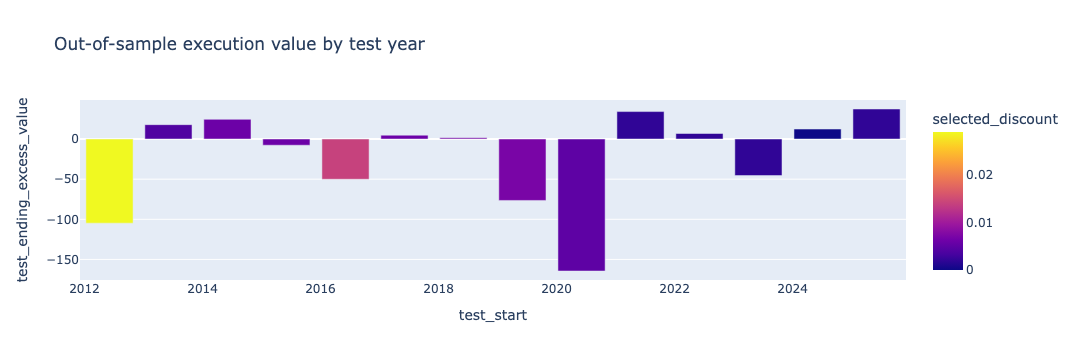

In [5]:
px.bar(
    walk_forward,
    x="test_start",
    y="test_ending_excess_value",
    color="selected_discount",
    title="Out-of-sample execution value by test year",
).show()

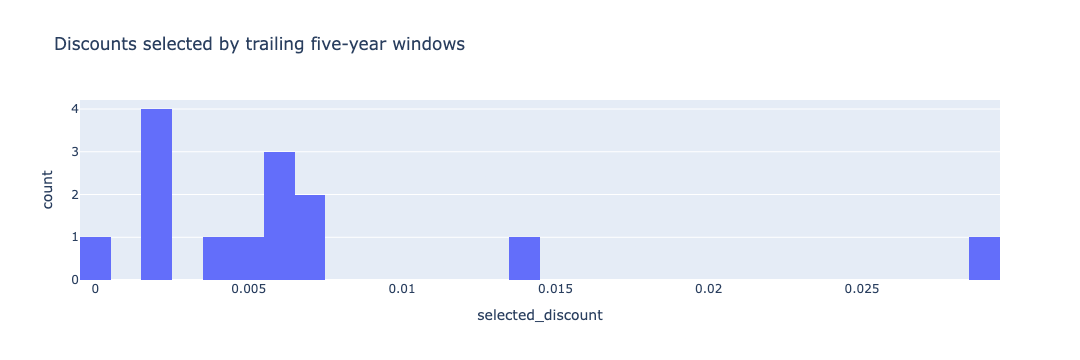

In [6]:
px.histogram(
    walk_forward,
    x="selected_discount",
    nbins=len(DISCOUNTS),
    title="Discounts selected by trailing five-year windows",
).show()

## Decision rule

Prefer a stable region that remains positive across many unseen folds. Do not select a single sharp in-sample maximum.